1st Test - Crutch segmentation - Image 3116 - 1920x1080

In [41]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [42]:
# Check shape
print(hsv_img.shape) # Result: (1080, 1920, 3)

(1080, 1920, 3)


In [43]:
# Get HSV color value
"""
OpenCV halves the H values to fit the range [0,255], so H value instead of being in range [0, 360], is in range [0, 180].
S and V are still in range [0, 255].
"""
import cv2 as cv
import numpy as np

# RGB => BGR (OpenCV)
# Color: Hex(#13647f) => RGB [19, 100, 127] => HSV (195°, 74%, 28%)
bgr_color = np.uint8([[[127, 100, 19]]])   #BGR (OpenCV)
hsv_color = cv.cvtColor(bgr_color, cv.COLOR_BGR2HSV)
print(hsv_color) # Expected value: [98, 217, 127] (Hue, Saturation, Value)

[[[ 98 217 127]]]


In [44]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"""
1st Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [95, 149, 187]
upper_bound = [95, 151, 188]

2nd Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [92, 132, 183]
upper_bound = [98, 151, 188]
"""


'\n1st Test:\nWriting down values (Hue, Saturation, Value)\nlower_bound = [95, 149, 187]\nupper_bound = [95, 151, 188]\n\n2nd Test:\nWriting down values (Hue, Saturation, Value)\nlower_bound = [92, 132, 183]\nupper_bound = [98, 151, 188]\n'

In [ ]:
# Preprocess (https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html)
# Apply blur to reduce noise
# hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)
# hsv_img = cv.GaussianBlur(hsv_img, (3,3), 0)

"""
Result: It doesn't help in this image (212)
"""

In [40]:
# Inspect the actual color values ​​in the image for each pixel after pre-process
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

"""
Writing down values (Hue, Saturation, Value) after pre-process, kernel 5x5
lower_bound = [0, 0, 0]
upper_bound = [0, 0, 0]

Writing down values (Hue, Saturation, Value) after pre-process, kernel 3x3
lower_bound = [0, 0, 0]
upper_bound = [0, 0, 0]
"""

'\nWriting down values (Hue, Saturation, Value) after pre-process, kernel 5x5\nlower_bound = [0, 0, 0]\nupper_bound = [0, 0, 0]\n\nWriting down values (Hue, Saturation, Value) after pre-process, kernel 3x3\nlower_bound = [0, 0, 0]\nupper_bound = [0, 0, 0]\n'

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

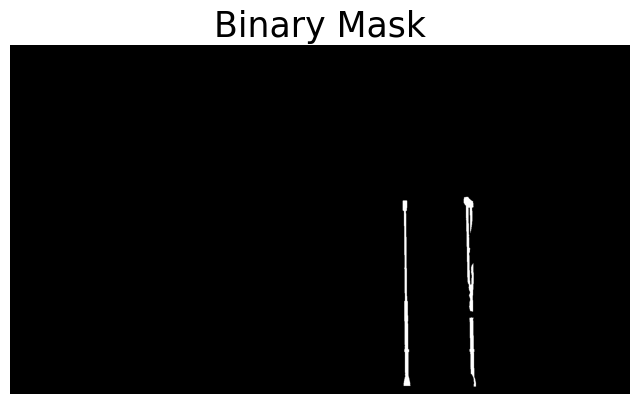

In [45]:
### Process 1 - One Range of HSV Values ###
# First Step - Limits
"""
1st Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [95, 149, 187]
upper_bound = [95, 151, 188]

2nd Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [92, 132, 183]
upper_bound = [98, 151, 188]
"""
# 1 - Define Human color limits >> HSV (H:92, S:132, V:183) to (H:98, S:151, V:188)
lower_bound = np.array([92, 132, 183]) # Hue, Saturation, Value   - Without pre-process - Result: Excellent
upper_bound = np.array([98, 151, 188]) # Hue, Saturation, Value   - Without pre-process - Result: Excellent

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [46]:
# 2.4 - Check Mask Values
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"\nKernel 1x1: OK, removed a few details\nKernel 3x3: Didn't improve the mask, removed details\n"

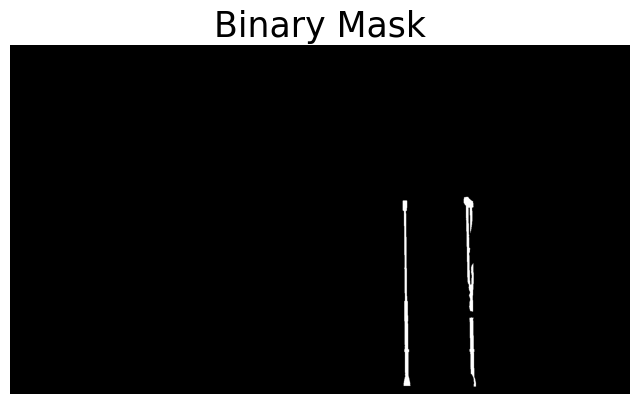

In [47]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((1,1), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Kernel 1x1: OK, removed a few details
Kernel 3x3: Didn't improve the mask, removed details
"""

In [17]:
# 3.5 - Check Mask values
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

'\nResult:\nmin_area = 5 >> , Does not compromise the image\n'

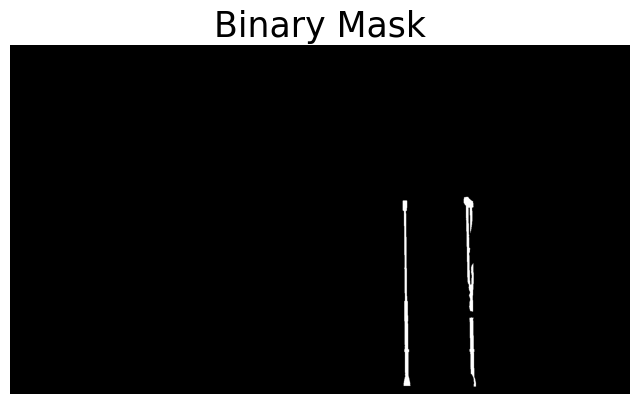

In [48]:
# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 5

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Result:
min_area = 5 >> , Does not compromise the image
"""

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

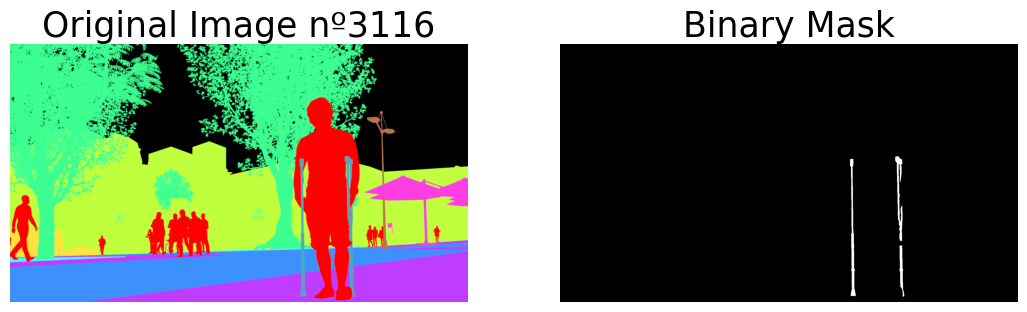

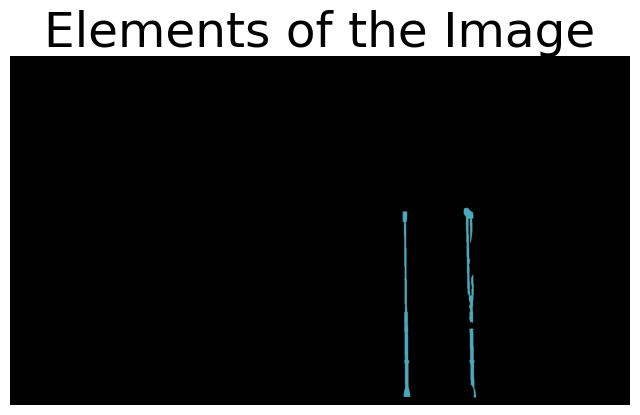

In [49]:
# Visualize Segmentation
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [50]:
# 3.5 - Check Result values
cv.imshow("Inspect Result", result)
cv.waitKey(0)
cv.destroyAllWindows()

2nd Test - Crutch Segmentation - Image 410 - 1920x1080 - WIP

In [66]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [ ]:
# Preprocess (https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html)
# Apply blur to reduce noise
# hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)
# hsv_img = cv.GaussianBlur(hsv_img, (3,3), 0)

"""
Result: It doesn't help in this image (410)
"""

"\nResult: It doesn't help in this image (410)\n"

In [55]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

"""
3rd Test with pre-process:
Writing down values (Hue, Saturation, Value)
lower_bound = [92, 132, 183]
upper_bound = [98, 151, 188]
"""

'\n3rd Test with pre-process:\nWriting down values (Hue, Saturation, Value)\nlower_bound = [92, 132, 183]\nupper_bound = [98, 151, 188]\n'

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

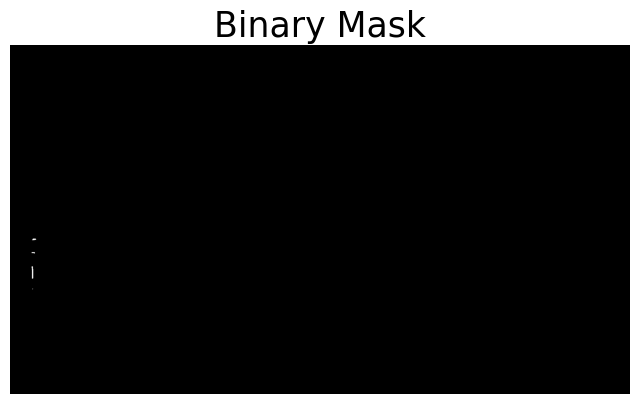

In [69]:
### Process 1 - One Range of HSV Values ###
# First Step - Limits
# 1 - Define Human color limits >> HSV (H:92, S:132, V:183) to (H:98, S:151, V:188)
lower_bound = np.array([92, 132, 183]) # Hue, Saturation, Value   - Without pre-process - Result: Excellent
upper_bound = np.array([98, 151, 188]) # Hue, Saturation, Value   - Without pre-process - Result: Excellent
# lower_bound = np.array([92, 26, 165]) # Hue, Saturation, Value   - With pre-process 5x5 - Result: Not good
# upper_bound = np.array([173, 151, 196]) # Hue, Saturation, Value   - With pre-process 5x5 - Result: Not good

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [57]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", mask)
cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

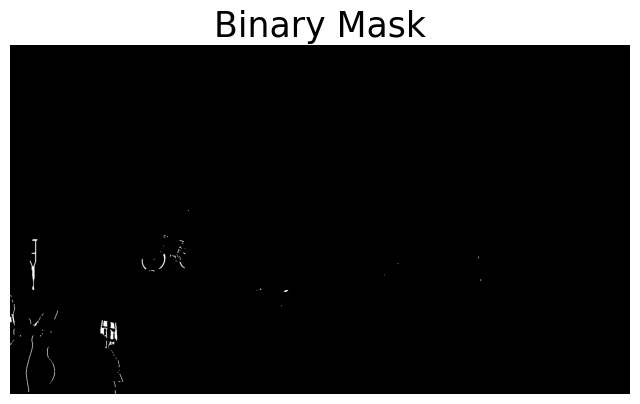

In [61]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((2,2), np.uint8) # Kernel 1x1 instead 3x3
mask1 = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask1 = cv.morphologyEx(mask1, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask1, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

'\nResult:\nmin_area = 5 >> , Does not compromise the image\n'

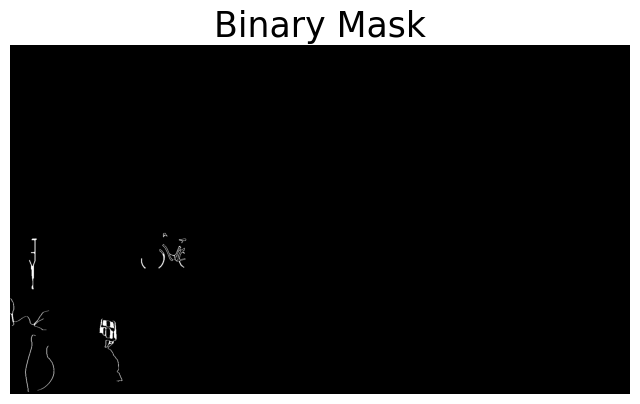

In [63]:
# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 50

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Result:
min_area = 5 >> , Does not compromise the image
"""

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

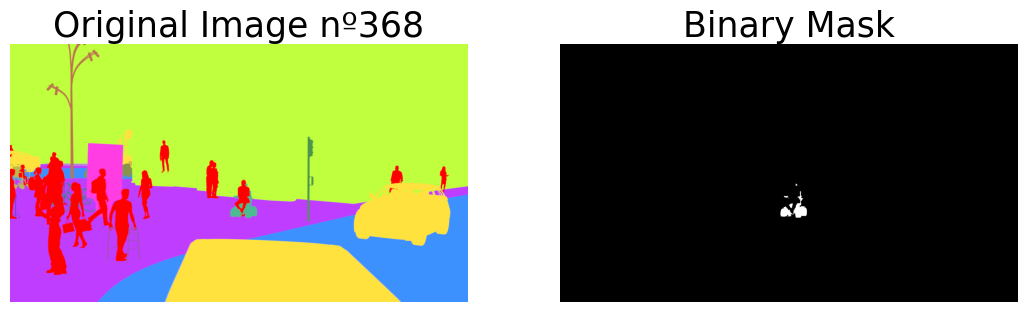

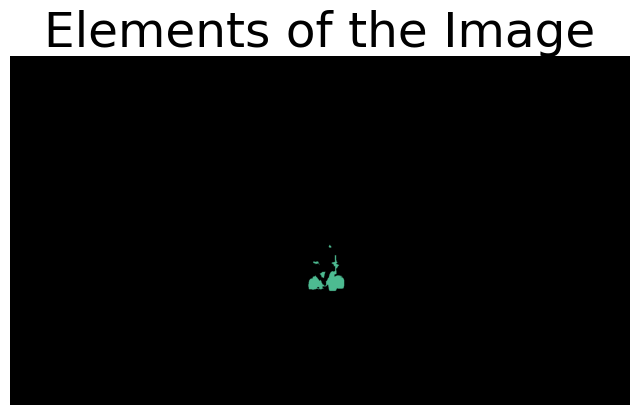

In [85]:
# Visualize Segmentation
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [86]:
# 3.5 - Check Result values
cv.imshow("Inspect Result", result)
cv.waitKey(0)
cv.destroyAllWindows()

3rd Test - Motorized Wheelchair Segmentation - Image 510 (Blur Effect) - 1920x1080

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

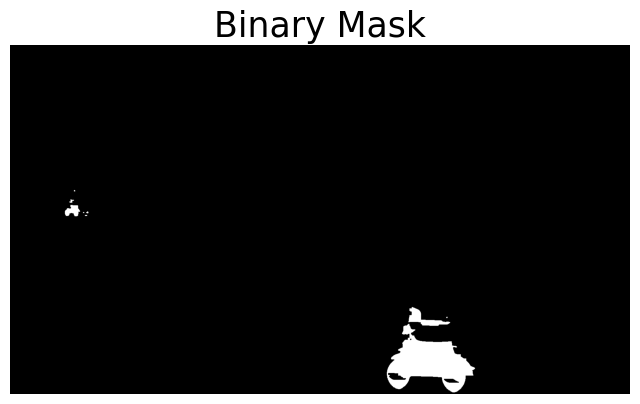

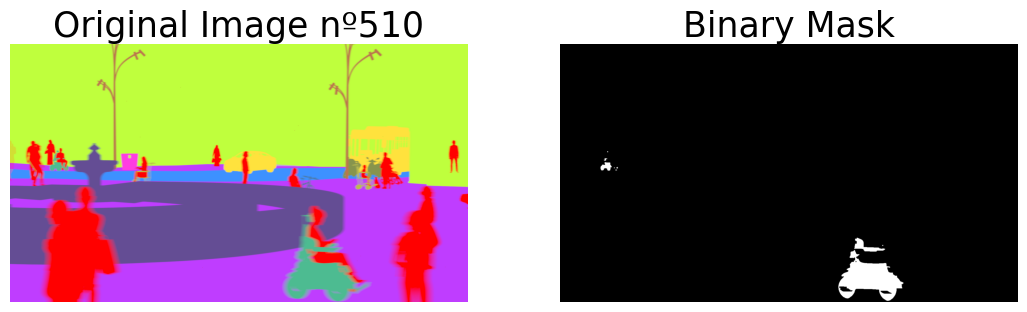

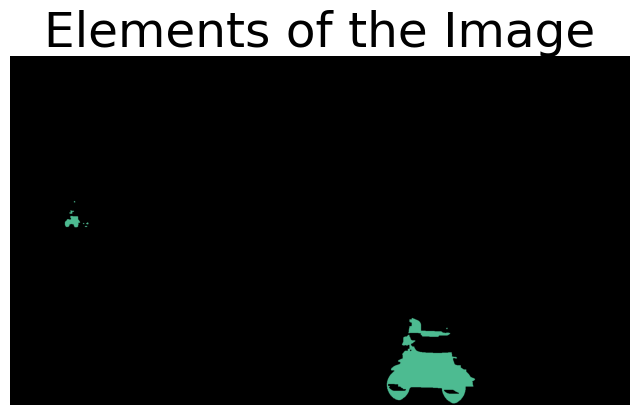

In [88]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

### Process 1 - One Range of HSV Values ###
# First Step - Limits
# 1 - Define color limits >> HSV (H:77, S:132, V:185) to (H:79, S:151, V:188)
lower_bound = np.array([77, 132, 185]) # Hue, Saturation, Value - Without pre-process - Result: Excellent
upper_bound = np.array([79, 151, 188]) # Hue, Saturation, Value - Without pre-process - Result: Excellent

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 5

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# Visualize Segmentation
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')